IMPORTAMOS LAS LIBRERIAS QUE USAREMOS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import classification_report

CARGAMOS EL DATASET

In [23]:
digits = load_digits()
x, y = digits.images, digits.target

NORMALIZAMOS LAS IMAGENES

In [24]:
x = x.astype("float32") / 16.0
x = np.expand_dims(x, axis=-1)

DIVIDIMOS EN ENTRENAMIENTO Y PRUEBA

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

MOSTRAMOS LOS DATOS

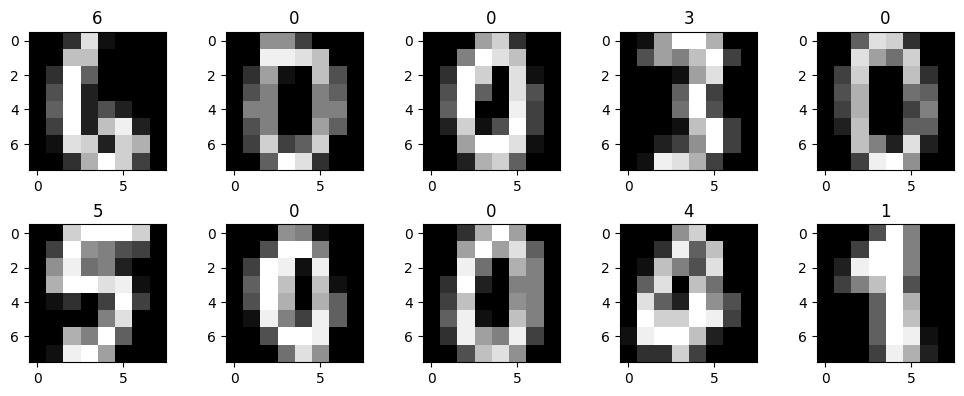

In [33]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(8, 8), cmap='gray')
    plt.title(y_train[i])
plt.tight_layout()
plt.show()

CREAMOS EL MODELO CONVOLUCIONAL Y ENTRENAMOS AL MODELO

In [34]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(8, 8, 1)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=20, verbose=0)

REALIZAMOS LAS PREDICCIONES Y LO MOSTRAMOS CON MATPLOTLIB

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


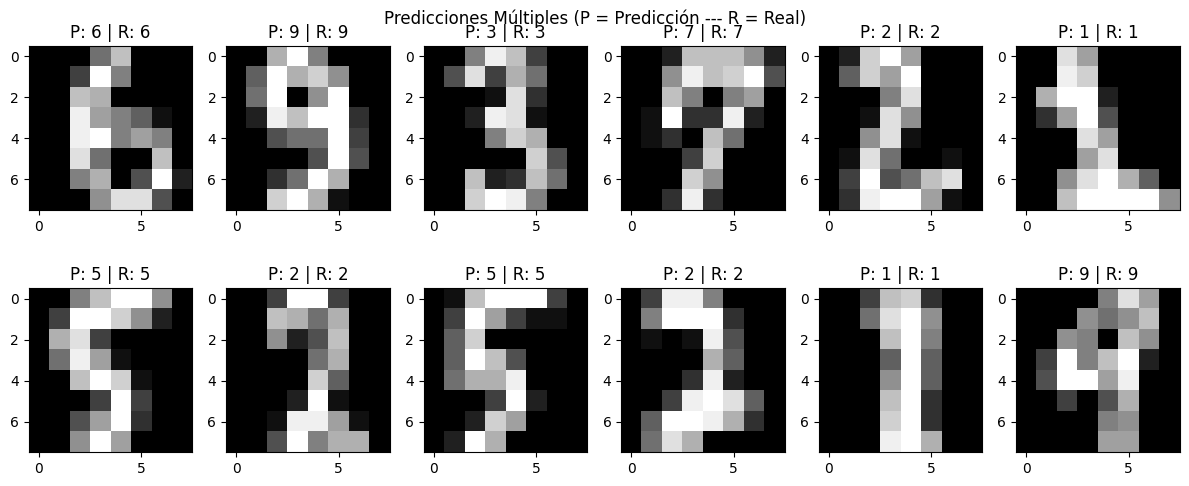

In [41]:
predict = model.predict(x_test)
predicted_labels = np.argmax(predict, axis=1)

plt.figure(figsize=(12, 5))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(x_test[i].reshape(8, 8), cmap='gray')
    plt.title(f"P: {predicted_labels[i]} | R: {y_test[i]}")
plt.tight_layout()
plt.suptitle("Predicciones Múltiples (P = Predicción --- R = Real)")
plt.show()

MOSTRAMOS LAS METRICAS

In [42]:
print("Métricas de Rendimiento del modelo:")
print(classification_report(y_test, predicted_labels))

Métricas de Rendimiento del modelo:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.93      0.93      0.93        28
           2       0.94      0.97      0.96        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       1.00      0.94      0.97        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.97      0.95        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

